il data augmentation è fattp sul momento usando queste funzioni

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
# Standard library imports
from pathlib import Path
from typing import List, Tuple

import random

import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch import Tensor
from torch.utils.data import DataLoader, Dataset
import torchvision.models as models
from torchvision import transforms
from torchvision.transforms import functional as tF


In [16]:
ON_COLAB = True  # Set to False if running locally (and you dont have a GPU with driver appropriate)

#Aggiunta parti mancanti

In [17]:
class OxfordPetDataset(Dataset):
    def __init__(self, split: str, transform=None) -> None:
        super().__init__()

        if ON_COLAB:
            self.root = Path("/content/drive/MyDrive/dataset")
        else:
            self.root =  Path("dataset")                                    #Path("/home/liam/Desktop/magistrale/computervision/progetto/modulo_due/ipcv-assignment-2/dataset")
        self.split = split
        self.names, self.labels = self._get_names_and_labels()
        self.transform = transform

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx) -> Tuple[Tensor, int]:
        img_path = self.root / "images" / f"{self.names[idx]}.jpg"
        img = Image.open(img_path).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

    def get_num_classes(self) -> int:
        return max(self.labels) + 1

    def _get_names_and_labels(self) -> Tuple[List[str], List[int]]:
        names = []
        labels = []

        with open(self.root / "annotations" / f"{self.split}.txt") as f:
            for line in f:
                name, label = line.replace("\n", "").split(" ")
                names.append(name),
                labels.append(int(label) - 1)

        return names, labels

In [18]:
import os

path = '/content/drive/MyDrive/dataset'
print(os.listdir(path))

['annotations', 'images']


In [19]:

class Random90DegreeRotation:
    """Custom transform for 90-degree rotations with specific probabilities."""
    def __call__(self, img):
        prob = random.random()
        if prob < 0.5:
            return img  # No rotation
        elif prob < 0.75:
            return tF.rotate(img, angle=-90)  # Rotate 90 degrees left
        else:
            return tF.rotate(img, angle=90)  # Rotate 90 degrees right

class OuterRandomCrop:
    """Custom transform to randomly crop the same amount of pixels from each side of the image."""
    def __init__(self, max_pixels_to_crop):
        """
        Args:
            max_pixels_to_crop (int): The maximum number of pixels to subtract from each side of the image.
        """
        self.max_pixels_to_crop = max_pixels_to_crop

    def __call__(self, img):
        # decides whether to apply the crop (75% chance)
        if random.random() < 0.25:
            return img

        # randomly select the number of pixels to crop (between 0 and max_pixels_to_crop)
        pixels_to_crop = random.randint(0, self.max_pixels_to_crop)

        width, height = img.size
        crop_left = pixels_to_crop
        crop_top = pixels_to_crop
        crop_width = width - 2 * pixels_to_crop
        crop_height = height - 2 * pixels_to_crop

        if crop_width <= 0 or crop_height <= 0:
            raise ValueError("The number of pixels to crop is too large for the image dimensions.")

        return tF.crop(img, top=crop_top, left=crop_left, height=crop_height, width=crop_width)


convert_compatible = transforms.Compose([
    transforms.Resize((224, 224)),     # Deterministic resize
    transforms.ToTensor(),             # Format conversion only
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # image net normalization values
])

transform_data_augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),       # Random horizontal flip
    OuterRandomCrop(20),                 # Custom outer crop
    Random90DegreeRotation(),                    # Custom 90-degree rotation
    transforms.RandomRotation(10),              # Random rotation of ±10 degrees
    transforms.ColorJitter(brightness=0.4),      # Adjust brightness slightly
    transforms.Resize((224, 224)),
    transforms.ToTensor(),                       # Convert to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # Normalize using ImageNet stats
                         std=[0.229, 0.224, 0.225])
])
print("dkj")
# Create datasets
train_dataset = OxfordPetDataset('train', transform=transform_data_augmentation)
val_dataset = OxfordPetDataset('val', transform=convert_compatible)
test_dataset = OxfordPetDataset('test', transform=convert_compatible)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers = 2 )
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False,  num_workers = 2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False,  num_workers = 2)

dkj


transform_data_augmentation è la pipeline. viene passata come argomento al dataset train_dataset. se copi e incolli quella cella (la trovi anche sul notebook train_resnet) dovrebbe uscirti lo stesso augmentation

questa è la funzione di training

In [20]:
#NOTE NEW Train function and hyperparameters
print("="*70)
print("PART 2A: Fine-tuning with Part 1 hyperparameters")
print("="*70)

# Load pretrained ResNet-18
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model_2a = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Replace final layer for 37 classes (Oxford Pets)
num_classes = train_dataset.get_num_classes()
model_2a.fc = nn.Linear(model_2a.fc.in_features, num_classes)

# Hyperparameters from Part 1 (based on your best model) ##NOTE: Adjust as needed
lr_2a = 3e-4
weight_decay_2a = 1e-4
num_epochs_2a = 80
one_cycle_max_lr_2a = 4e-3

# Setup training components
criterion_2a = nn.CrossEntropyLoss()
optimizer_2a = optim.AdamW(model_2a.parameters(), lr=lr_2a, weight_decay=weight_decay_2a)

# OneCycleLR scheduler (same as Part 1)
steps_per_epoch = len(train_loader)
scheduler_2a = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_2a,
    max_lr=one_cycle_max_lr_2a,
    epochs=num_epochs_2a,
    steps_per_epoch=steps_per_epoch
)

# Custom training loop with OneCycleLR stepping per batch
def train_model_onecycle(model, train_loader, val_loader, criterion, optimizer,
                        scheduler, num_epochs, device, model_name="model"):
    """Training function with OneCycleLR that steps per batch"""
    model.to(device)

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'lr': []
    }

    best_val_acc = 0.0
    best_model_wts = model.state_dict().copy()

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 40)

        # Training phase
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_samples = 0

        for batch_idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()
            scheduler.step()  # Step per batch for OneCycleLR

            # Statistics
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            total_samples += inputs.size(0)

        train_loss = running_loss / total_samples
        train_acc = running_corrects.double() / total_samples * 100

        # Validation phase
        model.eval()
        val_running_loss = 0.0
        val_running_corrects = 0
        val_total_samples = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_running_corrects += torch.sum(preds == labels.data)
                val_total_samples += inputs.size(0)

        val_loss = val_running_loss / val_total_samples
        val_acc = val_running_corrects.double() / val_total_samples * 100

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = model.state_dict().copy()

        # Store metrics
        current_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc.cpu().numpy())
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc.cpu().numpy())
        history['lr'].append(current_lr)

        print(f'Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}%')
        print(f'Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%')
        print(f'LR: {current_lr:.2e}')
        print()

    # Load best model weights
    model.load_state_dict(best_model_wts)
    print(f'Best Validation Accuracy: {best_val_acc:.2f}%')

    # Save model
    torch.save(model.state_dict(), f'{model_name}_best.pth')

    return model, history






PART 2A: Fine-tuning with Part 1 hyperparameters
Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 156MB/s]


puoi usare questa funzione per vedere se ti escono delle immagini simili a quelle sul notebook

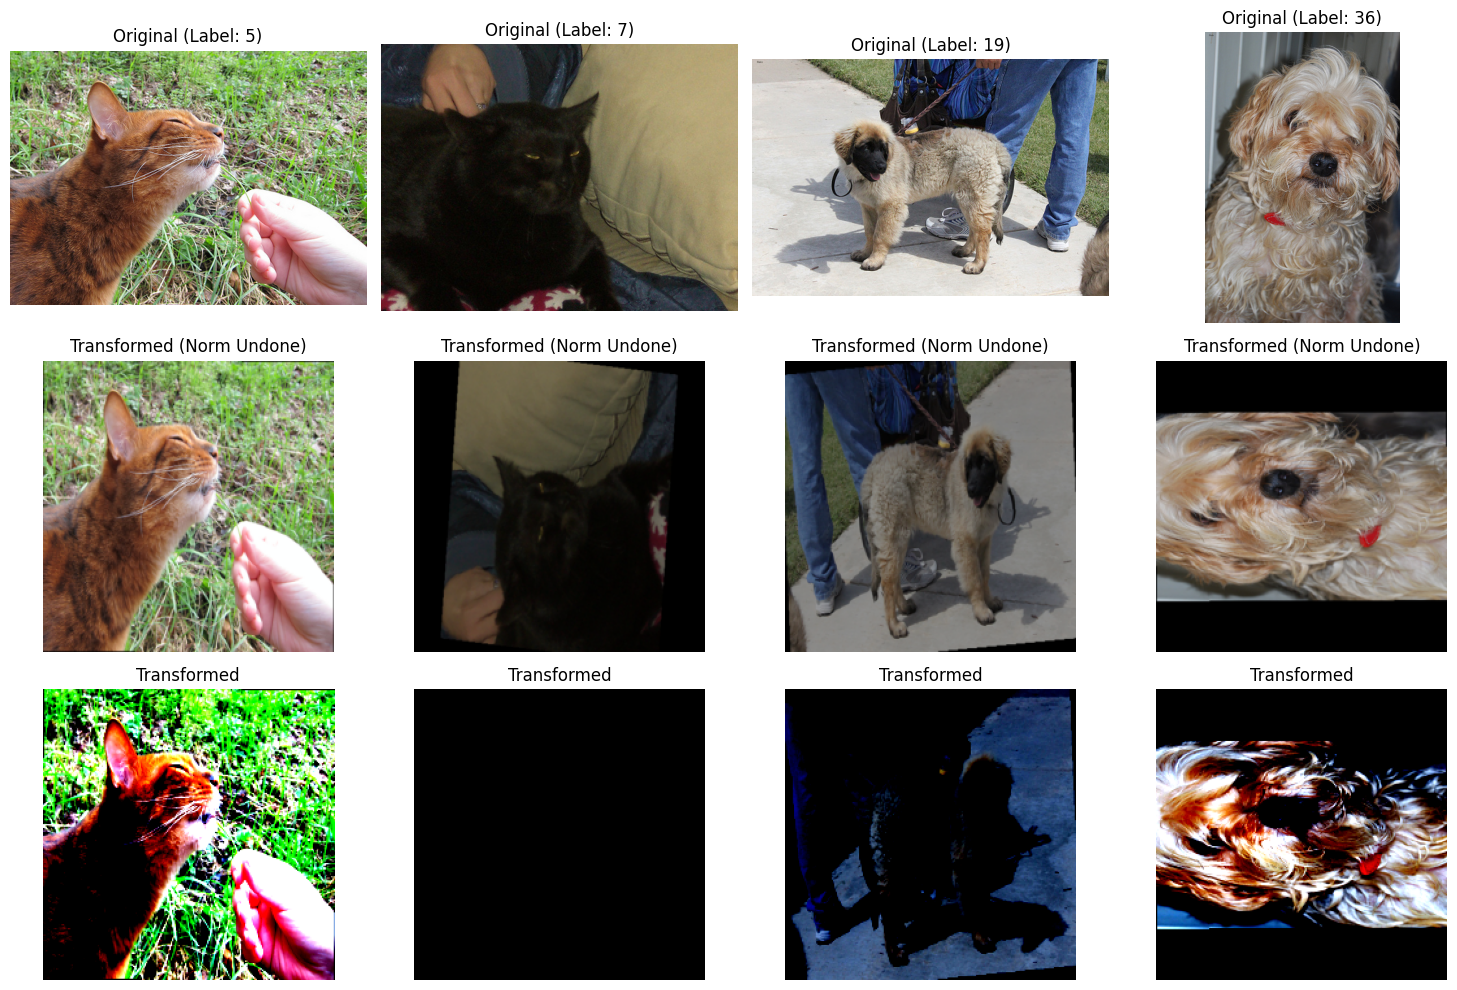

In [21]:
import matplotlib.pyplot as plt

# Function to display images
def display_image_comparison(dataset, num_images=4):
    fig, axes = plt.subplots(3, num_images, figsize=(15, 10))  # 3 rows, num_images columns

    for i in range(num_images):
        # Randomly select an image from the dataset
        idx = random.randint(0, len(dataset) - 1)

        # Access the raw image without applying the dataset's transform
        img_path = dataset.root / "images" / f"{dataset.names[idx]}.jpg"
        original_img = Image.open(img_path).convert("RGB")  # Load as PIL image
        label = dataset.labels[idx]

        # Apply your transformation
        transformed_with_norm = transform_data_augmentation(original_img)  # Fully transformed with normalization

        # Undo normalization for visualization
        mean = [0.485, 0.456, 0.406]
        std = [0.229, 0.224, 0.225]
        transformed_with_norm_np = transformed_with_norm.permute(1, 2, 0).numpy()
        transformed_no_norm_np = std * transformed_with_norm_np + mean  # Undo normalization
        transformed_no_norm_np = transformed_no_norm_np.clip(0, 1)

        # Display original image
        axes[0, i].imshow(original_img)
        axes[0, i].set_title(f"Original (Label: {label})")
        axes[0, i].axis("off")

        # Display transformed image with normalization undone
        axes[1, i].imshow(transformed_no_norm_np)
        axes[1, i].set_title("Transformed (Norm Undone)")
        axes[1, i].axis("off")

        # Display fully transformed image (with normalization)
        axes[2, i].imshow(transformed_with_norm_np)
        axes[2, i].set_title("Transformed")
        axes[2, i].axis("off")

    plt.tight_layout()
    plt.show()

# Call the function to display the comparison
display_image_comparison(train_dataset, num_images=4)

In [22]:
#General Utility functions

def test_accuracy(model, test_loader, device):
    """Calculate test accuracy"""
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

def plot_training_curves(history, title="Training History"):
    """Plot training and validation loss/accuracy"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss plot
    ax1.plot(history['train_loss'], label='Training Loss', marker='o')
    ax1.plot(history['val_loss'], label='Validation Loss', marker='s')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # Accuracy plot
    ax2.plot(history['train_acc'], label='Training Accuracy', marker='o')
    ax2.plot(history['val_acc'], label='Validation Accuracy', marker='s')
    ax2.set_title('Training and Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                num_epochs, device, model_name="model"):
    """
    Training function with comprehensive logging
    """
    model.to(device)

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'lr': []
    }

    best_val_acc = 0.0
    best_model_wts = model.state_dict().copy()

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 40)

        # Training phase
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_samples = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            # Statistics
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            total_samples += inputs.size(0)

        # Step scheduler if it's not OneCycleLR (which steps per batch)
        if not isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR):
            scheduler.step()

        train_loss = running_loss / total_samples
        train_acc = running_corrects.double() / total_samples * 100

        # Validation phase
        model.eval()
        val_running_loss = 0.0
        val_running_corrects = 0
        val_total_samples = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_running_corrects += torch.sum(preds == labels.data)
                val_total_samples += inputs.size(0)

        val_loss = val_running_loss / val_total_samples
        val_acc = val_running_corrects.double() / val_total_samples * 100

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = model.state_dict().copy()

        # Store metrics
        current_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc.cpu().numpy())
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc.cpu().numpy())
        history['lr'].append(current_lr)

        print(f'Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}%')
        print(f'Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%')
        print(f'LR: {current_lr:.2e}')
        print()

    # Load best model weights
    model.load_state_dict(best_model_wts)
    print(f'Best Validation Accuracy: {best_val_acc:.2f}%')

    # Save model
    torch.save(model.state_dict(), f'{model_name}_best.pth')

    return model, history


Prepare the data

Training with Part 1 hyperparameters...
Epoch 1/80
----------------------------------------
Train Loss: 1.7402 Acc: 56.61%
Val Loss: 0.7933 Acc: 78.79%
LR: 1.76e-04

Epoch 2/80
----------------------------------------
Train Loss: 0.7350 Acc: 80.19%
Val Loss: 0.8065 Acc: 75.90%
LR: 2.25e-04

Epoch 3/80
----------------------------------------
Train Loss: 0.6507 Acc: 80.87%
Val Loss: 0.8083 Acc: 74.75%
LR: 3.06e-04

Epoch 4/80
----------------------------------------
Train Loss: 0.6462 Acc: 80.46%
Val Loss: 1.0383 Acc: 66.68%
LR: 4.17e-04

Epoch 5/80
----------------------------------------
Train Loss: 0.7352 Acc: 77.08%
Val Loss: 2.1021 Acc: 52.34%
LR: 5.57e-04

Epoch 6/80
----------------------------------------
Train Loss: 0.8268 Acc: 73.89%
Val Loss: 1.9296 Acc: 50.11%
LR: 7.23e-04

Epoch 7/80
----------------------------------------
Train Loss: 0.9887 Acc: 69.66%
Val Loss: 2.6956 Acc: 36.64%
LR: 9.12e-04

Epoch 8/80
----------------------------------------
Train Loss: 1.1084 Acc: 65

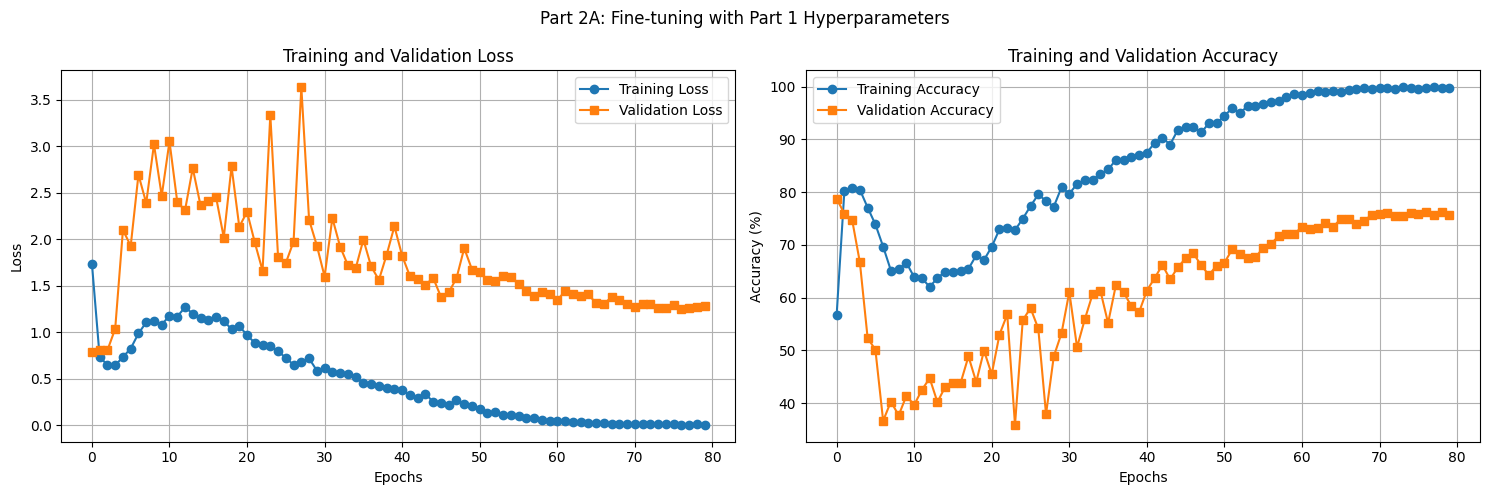

In [23]:
print("Training with Part 1 hyperparameters...")
model_2a, history_2a = train_model_onecycle(
    model_2a, train_loader, val_loader, criterion_2a, optimizer_2a,
    scheduler_2a, num_epochs_2a, device, "resnet18_finetune_2a"
)

# Evaluate on test set
test_acc_2a = test_accuracy(model_2a, test_loader, device)
print(f"\nPart 2A Test Accuracy: {test_acc_2a:.2f}%")

# Plot training curves
plot_training_curves(history_2a, "Part 2A: Fine-tuning with Part 1 Hyperparameters")


In [24]:
#Save model in drive (not requested, useful to rerun after first training sect. if needed)
import os

drive_save_directory = "/content/drive/MyDrive/saved_models"
os.makedirs(drive_save_directory, exist_ok=True)
print(f"WEIGHTS SAVED TO : {drive_save_directory}")


best_weights_path = Path(drive_save_directory) / "weights_2A_BEST_model.pth"

print(f"\SAVING BEST  MODEL WEIGHTS OF CURRENT SECTION TO: {best_weights_path}")
torch.save(model_2a.state_dict(), best_weights_path)


WEIGHTS SAVED TO : /content/drive/MyDrive/saved_models
\SAVING BEST  MODEL WEIGHTS OF CURRENT SECTION TO: /content/drive/MyDrive/saved_models/weights_2A_BEST_model.pth


<>:11: SyntaxWarning: invalid escape sequence '\S'
<>:11: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipython-input-3539346163.py:11: SyntaxWarning: invalid escape sequence '\S'
  print(f"\SAVING BEST  MODEL WEIGHTS OF CURRENT SECTION TO: {best_weights_path}")


# Section 2 B


In [1]:
#Specs
print("\n" + "="*70)
print("PART 2B: Optimized hyperparameters")
print("="*70)

"""
HYPERPARAMETER OPTIMIZATION STRATEGY:
=====================================

Based on transfer learning best practices and analysis of Part 2A results:

1. **Lower Learning Rate**: For fine-tuning, we typically use lower LRs than training from scratch
   - Start with 1e-4 to 1e-5 for better feature preservation
   - Use a gentler learning rate schedule

2. **Differential Learning Rates**: Apply different LRs to different parts of the network
   - Lower LR for early layers (frozen or nearly frozen features)
   - Higher LR for later layers and the new classifier head

3. **Warmup + Cosine Annealing**: More stable than OneCycleLR for fine-tuning
   - Gradual warmup prevents early overfitting
   - Cosine decay for smooth convergence

4. **Extended Training**: Fine-tuning often benefits from more epochs
   - 100-150 epochs with proper regularization

5. **Enhanced Regularization**:
   - Dropout in classifier head (0.3-0.5)
   - Label smoothing to prevent overconfidence
   - Stronger weight decay for classifier layers

6. **Batch Size Considerations**:
   - Smaller batches (16-32) often work better for fine-tuning
   - Better gradient estimates for small datasets

Sources:
- "How transferable are features in deep neural networks?" (Yosinski et al., 2014)
- "Visualizing and Understanding Convolutional Networks" (Zeiler & Fergus, 2014)
- "Bag of Tricks for Image Classification with Convolutional Neural Networks" (He et al., 2019)
- PyTorch Transfer Learning Tutorial
"""



PART 2B: Optimized hyperparameters


'\nHYPERPARAMETER OPTIMIZATION STRATEGY:\n=====================================\n\nBased on transfer learning best practices and analysis of Part 2A results:\n\n1. **Lower Learning Rate**: For fine-tuning, we typically use lower LRs than training from scratch\n   - Start with 1e-4 to 1e-5 for better feature preservation\n   - Use a gentler learning rate schedule\n\n2. **Differential Learning Rates**: Apply different LRs to different parts of the network\n   - Lower LR for early layers (frozen or nearly frozen features)\n   - Higher LR for later layers and the new classifier head\n\n3. **Warmup + Cosine Annealing**: More stable than OneCycleLR for fine-tuning\n   - Gradual warmup prevents early overfitting\n   - Cosine decay for smooth convergence\n\n4. **Extended Training**: Fine-tuning often benefits from more epochs\n   - 100-150 epochs with proper regularization\n\n5. **Enhanced Regularization**:\n   - Dropout in classifier head (0.3-0.5)\n   - Label smoothing to prevent overconfide

In [26]:
#NOTE SetUp

# Create optimized model
model_2b = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1) # NOTE as specs

# Replace classifier with dropout for better regularization
model_2b.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(model_2b.fc.in_features, num_classes)
)

# Optimized hyperparameters
lr_backbone_2b = 1e-5    # Very low LR for pretrained features
lr_classifier_2b = 1e-3  # Higher LR for new classifier
weight_decay_2b = 1e-3   # Increased regularization
num_epochs_2b = 120      # More epochs for convergence
batch_size_2b = 16       # Smaller batches

# Create new data loaders with smaller batch size
train_loader_2b = DataLoader(train_dataset, batch_size=batch_size_2b, shuffle=True, num_workers=4)
val_loader_2b = DataLoader(val_dataset, batch_size=batch_size_2b, shuffle=False, num_workers=4)

# Differential learning rates
backbone_params = []
classifier_params = []

for name, param in model_2b.named_parameters():
    if 'fc' in name:
        classifier_params.append(param)
    else:
        backbone_params.append(param)

# Setup optimizer with different learning rates
optimizer_2b = optim.AdamW([
    {'params': backbone_params, 'lr': lr_backbone_2b, 'weight_decay': weight_decay_2b},
    {'params': classifier_params, 'lr': lr_classifier_2b, 'weight_decay': weight_decay_2b * 10}
], lr=lr_classifier_2b)

# Label smoothing for better generalization
criterion_2b = nn.CrossEntropyLoss(label_smoothing=0.1)

# Cosine annealing scheduler with warmup
def get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps):
    """Create a schedule with a learning rate that decreases following the values of the cosine function"""

    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(0.0, 0.5 * (1.0 + np.cos(np.pi * progress)))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Calculate steps for scheduler
steps_per_epoch_2b = len(train_loader_2b)
total_steps_2b = steps_per_epoch_2b * num_epochs_2b
warmup_steps_2b = steps_per_epoch_2b * 5  # 5 epochs warmup

scheduler_2b = get_cosine_schedule_with_warmup(
    optimizer_2b,
    num_warmup_steps=warmup_steps_2b,
    num_training_steps=total_steps_2b
)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [27]:
#Training def, training and data log
def train_model_optimized(model, train_loader, val_loader, criterion, optimizer,
                         scheduler, num_epochs, device, model_name="model"):
    """Enhanced training function with detailed logging"""
    model.to(device)

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'lr_backbone': [],
        'lr_classifier': []
    }

    best_val_acc = 0.0
    best_model_wts = model.state_dict().copy()
    patience = 15  # Early stopping patience
    patience_counter = 0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 40)

        # Training phase
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_samples = 0

        for batch_idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()

            # Gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            scheduler.step()  # Step per batch

            # Statistics
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            total_samples += inputs.size(0)

        train_loss = running_loss / total_samples
        train_acc = running_corrects.double() / total_samples * 100

        # Validation phase
        model.eval()
        val_running_loss = 0.0
        val_running_corrects = 0
        val_total_samples = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_running_corrects += torch.sum(preds == labels.data)
                val_total_samples += inputs.size(0)

        val_loss = val_running_loss / val_total_samples
        val_acc = val_running_corrects.double() / val_total_samples * 100

        # Early stopping and best model saving
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1

        # Store metrics
        backbone_lr = optimizer.param_groups[0]['lr']
        classifier_lr = optimizer.param_groups[1]['lr']

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc.cpu().numpy())
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc.cpu().numpy())
        history['lr_backbone'].append(backbone_lr)
        history['lr_classifier'].append(classifier_lr)

        print(f'Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}%')
        print(f'Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%')
        print(f'LR Backbone: {backbone_lr:.2e}, Classifier: {classifier_lr:.2e}')
        print(f'Patience: {patience_counter}/{patience}')
        print()

        # Early stopping
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break

    # Load best model weights
    model.load_state_dict(best_model_wts)
    print(f'Best Validation Accuracy: {best_val_acc:.2f}%')

    # Save model
    torch.save(model.state_dict(), f'{model_name}_best.pth')

    return model, history

# Train optimized model
print("Training with optimized hyperparameters...")
model_2b, history_2b = train_model_optimized(
    model_2b, train_loader_2b, val_loader_2b, criterion_2b, optimizer_2b,
    scheduler_2b, num_epochs_2b, device, "resnet18_finetune_2b_optimized"
)

# Evaluate on test set
test_acc_2b = test_accuracy(model_2b, test_loader, device)


Training with optimized hyperparameters...
Epoch 1/120
----------------------------------------
Train Loss: 3.7969 Acc: 4.36%
Val Loss: 3.1900 Acc: 19.68%
LR Backbone: 2.00e-06, Classifier: 2.00e-04
Patience: 0/15

Epoch 2/120
----------------------------------------
Train Loss: 2.9617 Acc: 24.99%
Val Loss: 2.0122 Acc: 66.85%
LR Backbone: 4.00e-06, Classifier: 4.00e-04
Patience: 0/15

Epoch 3/120
----------------------------------------
Train Loss: 2.0833 Acc: 55.19%
Val Loss: 1.3859 Acc: 80.70%
LR Backbone: 6.00e-06, Classifier: 6.00e-04
Patience: 0/15

Epoch 4/120
----------------------------------------
Train Loss: 1.6771 Acc: 67.10%
Val Loss: 1.2686 Acc: 82.77%
LR Backbone: 8.00e-06, Classifier: 8.00e-04
Patience: 0/15

Epoch 5/120
----------------------------------------
Train Loss: 1.5178 Acc: 73.04%
Val Loss: 1.2568 Acc: 82.72%
LR Backbone: 1.00e-05, Classifier: 1.00e-03
Patience: 1/15

Epoch 6/120
----------------------------------------
Train Loss: 1.4428 Acc: 75.99%
Val Loss:


Part 2B Test Accuracy: 88.46%


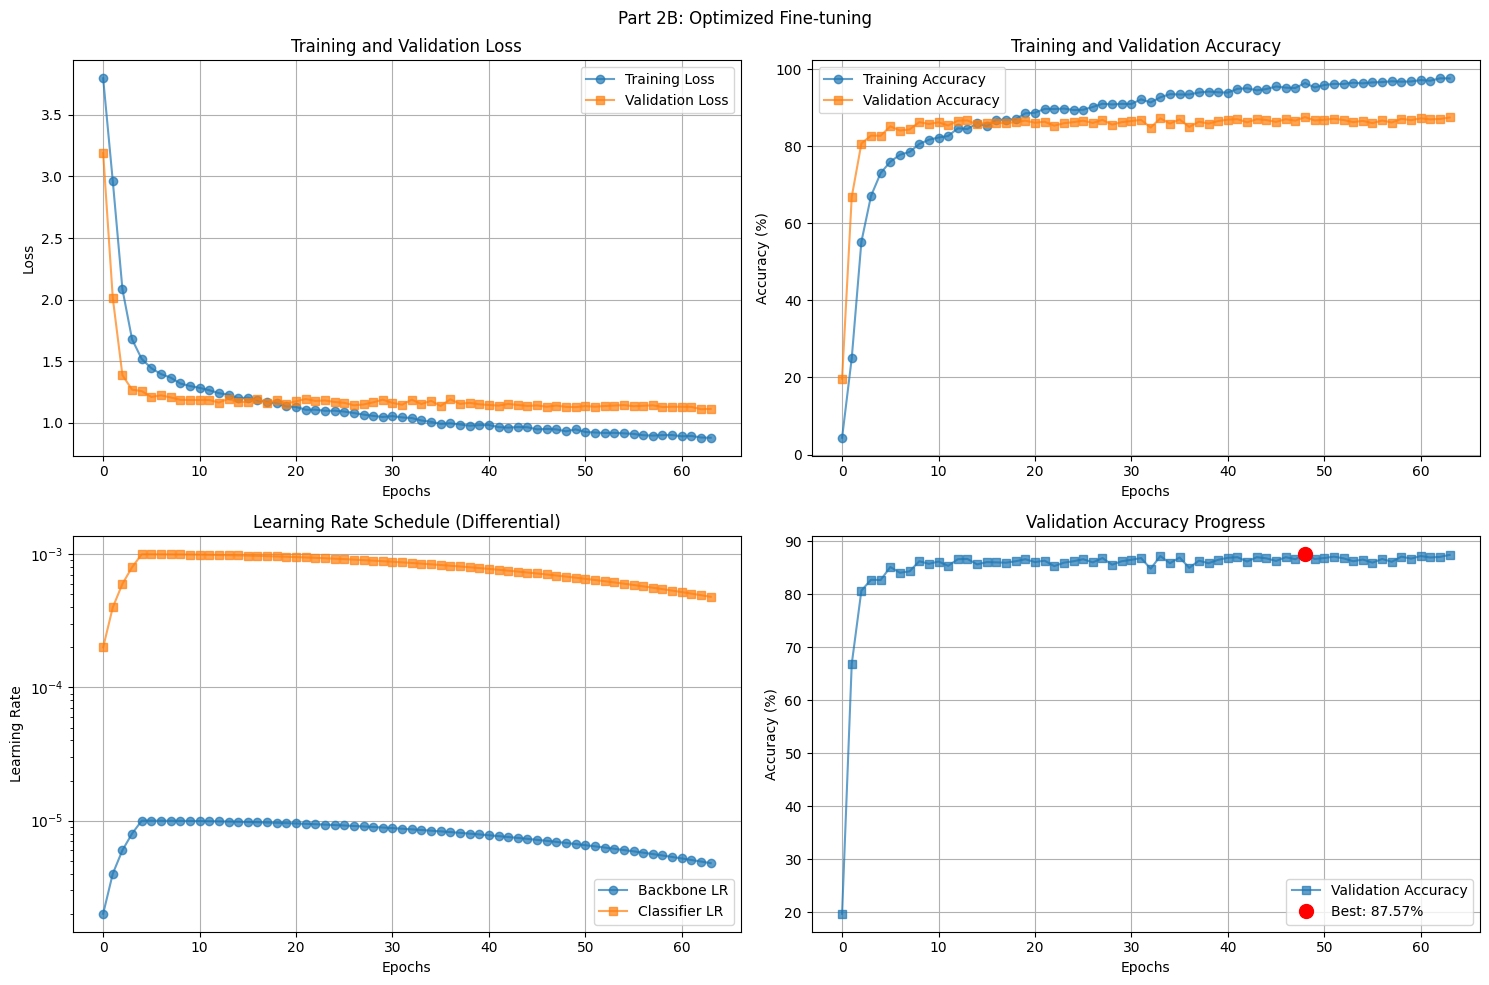

In [28]:
#Plot and print res
print(f"\nPart 2B Test Accuracy: {test_acc_2b:.2f}%")

# Enhanced plotting for Part 2B
def plot_training_curves_enhanced(history, title="Training History"):
    """Enhanced plotting with learning rate schedules"""
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

    # Loss plot
    ax1.plot(history['train_loss'], label='Training Loss', marker='o', alpha=0.7)
    ax1.plot(history['val_loss'], label='Validation Loss', marker='s', alpha=0.7)
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # Accuracy plot
    ax2.plot(history['train_acc'], label='Training Accuracy', marker='o', alpha=0.7)
    ax2.plot(history['val_acc'], label='Validation Accuracy', marker='s', alpha=0.7)
    ax2.set_title('Training and Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)

    # Learning rate plots
    if 'lr_backbone' in history:
        ax3.plot(history['lr_backbone'], label='Backbone LR', marker='o', alpha=0.7)
        ax3.plot(history['lr_classifier'], label='Classifier LR', marker='s', alpha=0.7)
        ax3.set_title('Learning Rate Schedule (Differential)')
        ax3.set_xlabel('Epochs')
        ax3.set_ylabel('Learning Rate')
        ax3.set_yscale('log')
        ax3.legend()
        ax3.grid(True)
    else:
        ax3.plot(history['lr'], label='Learning Rate', marker='o', alpha=0.7)
        ax3.set_title('Learning Rate Schedule')
        ax3.set_xlabel('Epochs')
        ax3.set_ylabel('Learning Rate')
        ax3.set_yscale('log')
        ax3.legend()
        ax3.grid(True)

    # Validation accuracy with best marker
    best_epoch = np.argmax(history['val_acc'])
    best_acc = history['val_acc'][best_epoch]

    ax4.plot(history['val_acc'], label='Validation Accuracy', marker='s', alpha=0.7)
    ax4.plot(best_epoch, best_acc, 'ro', markersize=10, label=f'Best: {best_acc:.2f}%')
    ax4.set_title('Validation Accuracy Progress')
    ax4.set_xlabel('Epochs')
    ax4.set_ylabel('Accuracy (%)')
    ax4.legend()
    ax4.grid(True)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_training_curves_enhanced(history_2b, "Part 2B: Optimized Fine-tuning")



From the plots, we observe that the training performed with the original hyperparameters (Part 2A) exhibits significantly higher volatility in both training and validation loss. The validation loss oscillates strongly across epochs and fails to stabilize, while the corresponding validation accuracy fluctuates widely before slowly improving. This indicates that the model struggled to converge reliably under the initial settings, leading to an unstable learning process and poorer generalization.

In contrast, the optimized fine-tuning setup (Part 2B) yields much smoother and more consistent curves. Both training and validation losses decrease steadily, and the accuracy metrics converge towards stable plateaus. Although a slight degree of overfitting is still present—as evidenced by the small but persistent gap between training and validation accuracy—the overall behavior is far more controlled. The model converges faster, the learning rate schedule behaves predictably, and performance on the validation set remains high and stable.

Overall, these results clearly show that the adjusted techniques and parameter tuning (learning-rate scheduling, regularization adjustments, and optimizer configuration) proved effective and appropriate. Compared to the earlier round, the new setup achieves notably better performance, improved stability, and stronger generalization, demonstrating that the refinements made during fine-tuning were well-justified and beneficial.